# Analyse du marché de l'emploi Data en Île-de-France

**Livrable IV — Analyse.**

> **Question fil rouge :** *Quelles compétences Data sont les plus demandées en
> Île-de-France et comment se valorisent-elles salarialement ?*

Source : API REST officielle France Travail (offres Data/BI/IA en IDF, `region=11`).
Ce notebook consomme les agrégats produits par `src/03_calculs.py` (il ne recalcule
rien de lourd) et les interprète pour répondre à la question ci-dessus.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

P = Path("..") / "data" / "processed"
kpi      = pd.read_csv(P / "kpi_global.csv")
top      = pd.read_csv(P / "top_competences.csv")
csal     = pd.read_csv(P / "competences_salaire.csv")
offres   = pd.read_csv(P / "offres_clean.csv")
dep      = pd.read_csv(P / "repartition_departement.csv")
exp      = pd.read_csv(P / "repartition_experience.csv")
contrat  = pd.read_csv(P / "repartition_contrat.csv")
print(f"{len(offres)} offres chargées.")

299 offres chargées.


## 1. Panorama du corpus

Volumétrie réellement collectée et structure des offres (périmètre, contrats,
expérience). Ces chiffres cadrent la portée — et les limites — de l'analyse.

In [2]:
kpi.T.rename(columns={0: "valeur"})

,valeur
nb_offres,299.000
nb_departements,8.000
nb_entreprises,97.000
nb_competences_distinctes,53.000
taux_salaire_renseigne,0.268
salaire_annuel_median,50000.000
salaire_annuel_q1,37326.000
salaire_annuel_q3,56358.000


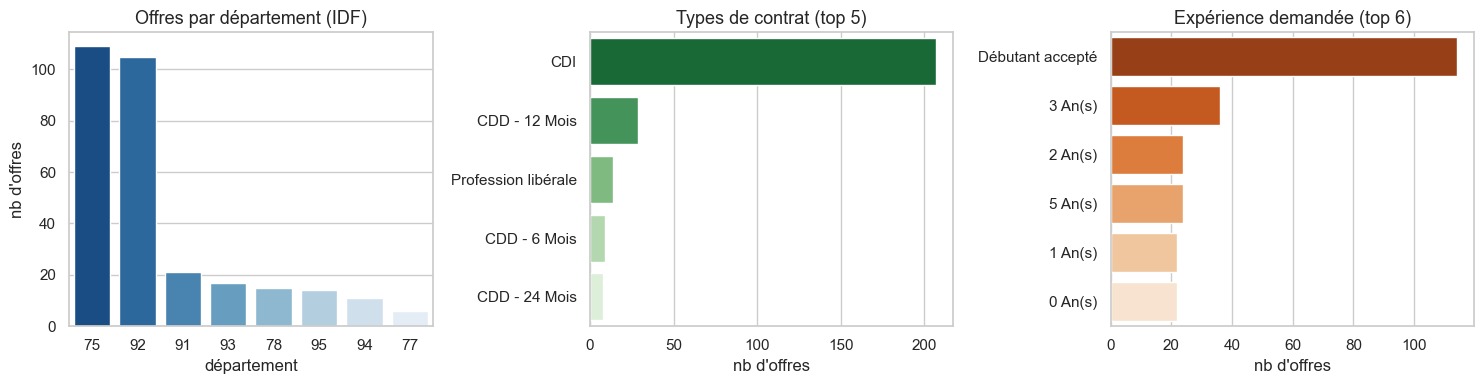

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

d = dep.dropna(subset=["departement"]).copy()
d["departement"] = d["departement"].astype(int).astype(str)
d = d.sort_values("nb_offres", ascending=False)
sns.barplot(data=d, x="departement", y="nb_offres", ax=axes[0],
            palette="Blues_r", hue="departement", legend=False)
axes[0].set_title("Offres par département (IDF)")
axes[0].set_xlabel("département"); axes[0].set_ylabel("nb d'offres")

c = contrat.dropna().sort_values("nb_offres", ascending=False).head(5)
sns.barplot(data=c, y="typeContratLibelle", x="nb_offres", ax=axes[1],
            palette="Greens_r", hue="typeContratLibelle", legend=False)
axes[1].set_title("Types de contrat (top 5)")
axes[1].set_xlabel("nb d'offres"); axes[1].set_ylabel("")

e = exp.dropna().sort_values("nb_offres", ascending=False).head(6)
sns.barplot(data=e, y="experienceLibelle", x="nb_offres", ax=axes[2],
            palette="Oranges_r", hue="experienceLibelle", legend=False)
axes[2].set_title("Expérience demandée (top 6)")
axes[2].set_xlabel("nb d'offres"); axes[2].set_ylabel("")

plt.tight_layout(); plt.show()

On observe une **forte concentration sur Paris (75) et les Hauts-de-Seine (92)**,
qui regroupent l'essentiel des offres Data d'Île-de-France — cohérent avec la
localisation des sièges et ESN. Le **CDI domine** largement les types de contrat.

## 2. Compétences les plus demandées

Compétences détectées dans les offres (champ structuré `competences[]` complété
par détection lexicale sur l'intitulé et la description, cf. `02_nettoyage.py`).

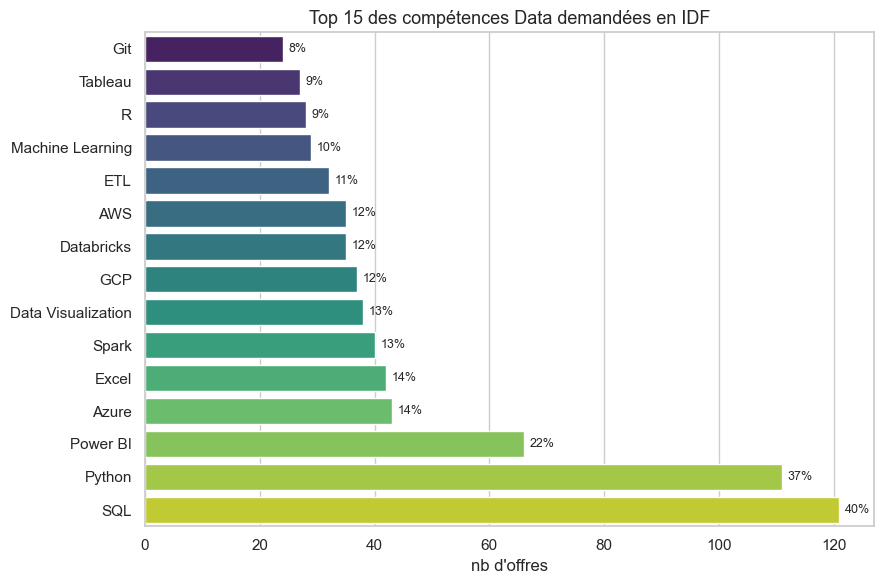

In [4]:
t = top.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=t, y="competence", x="nb_offres", palette="viridis",
            hue="competence", legend=False, ax=ax)
ax.set_title("Top 15 des compétences Data demandées en IDF")
ax.set_xlabel("nb d'offres"); ax.set_ylabel("")
for i, (n, p) in enumerate(zip(t["nb_offres"], t["part_offres"])):
    ax.text(n + 1, i, f"{p:.0%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**SQL** et **Python** forment le socle incontournable, présents dans une large
part des offres. Viennent ensuite la **BI / dataviz** (Power BI, Tableau, Excel)
et l'écosystème **cloud / big data** (Azure, GCP, AWS, Spark, Databricks). La
demande dessine deux familles : un noyau analytique (SQL/Python/BI) et une couche
d'ingénierie de la donnée (cloud, traitement distribué).

## 3. Distribution des salaires

Salaires normalisés en base **annuelle** (cf. parsing de `salaire.libelle`).
Rappel : le salaire n'est renseigné que sur une minorité d'offres — distribution
à lire avec prudence.

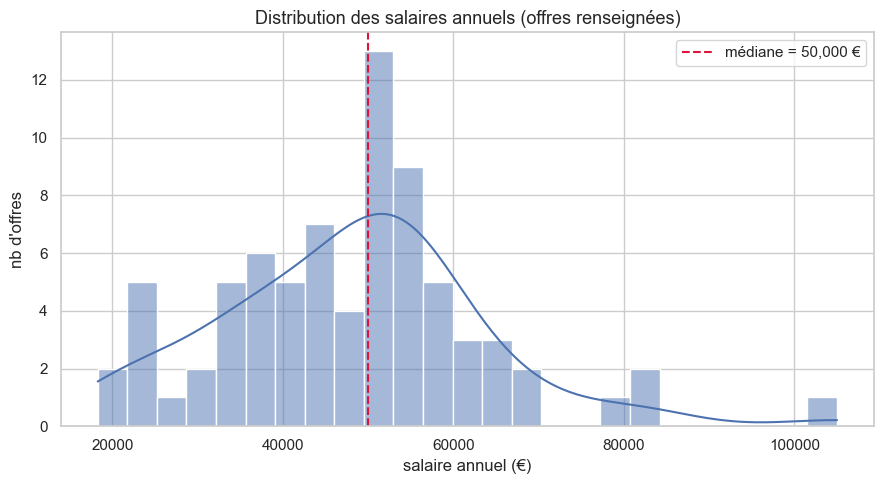

n = 76 offres avec salaire exploitable


In [5]:
sal = offres["sal_annuel_moyen"].dropna()
sal = sal[sal.between(15000, 150000)]  # bornes lisibles (écarte outliers extrêmes)
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(sal, bins=25, kde=True, color="#4C72B0", ax=ax)
ax.axvline(sal.median(), color="crimson", ls="--",
           label=f"médiane = {sal.median():,.0f} €")
ax.set_title("Distribution des salaires annuels (offres renseignées)")
ax.set_xlabel("salaire annuel (€)"); ax.set_ylabel("nb d'offres")
ax.legend(); plt.tight_layout(); plt.show()
print(f"n = {len(sal)} offres avec salaire exploitable")

## 4. Valorisation salariale par compétence

Cœur de la question : on croise chaque compétence au salaire annuel médian des
offres qui la mentionnent (effectif salarié ≥ 5 pour la fiabilité). Les barres
d'erreur représentent l'intervalle interquartile (Q1–Q3).

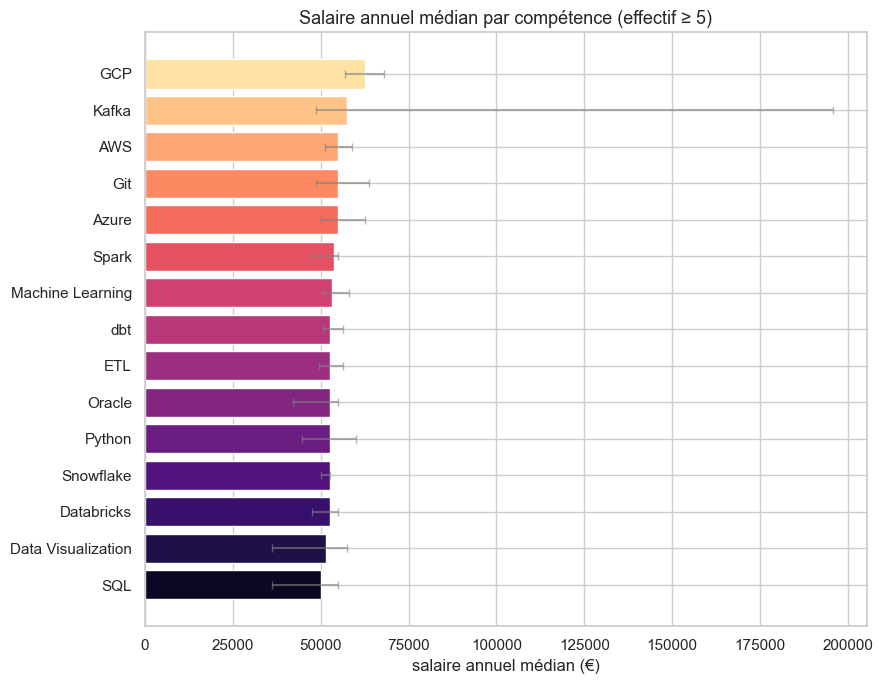

In [6]:
cs = csal.sort_values("salaire_median", ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(9, 7))
err = [cs["salaire_median"] - cs["salaire_q1"], cs["salaire_q3"] - cs["salaire_median"]]
ax.barh(cs["competence"], cs["salaire_median"], color=sns.color_palette("magma", len(cs)),
        xerr=err, error_kw=dict(ecolor="gray", alpha=0.6, capsize=3))
ax.set_title("Salaire annuel médian par compétence (effectif ≥ 5)")
ax.set_xlabel("salaire annuel médian (€)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

Les compétences les mieux rémunérées relèvent du **cloud et du big data**
(GCP, AWS, Azure, Spark, Kafka, Databricks, Snowflake), au-dessus du socle
analytique. La maîtrise de l'infrastructure de données se valorise donc davantage
que les seuls outils de BI.

## 5. Synthèse : demande × valorisation

On positionne chaque compétence selon sa **demande** (axe X) et sa **valorisation
salariale médiane** (axe Y). Cela distingue les compétences *socle* (très demandées)
des compétences *premium* (mieux payées).

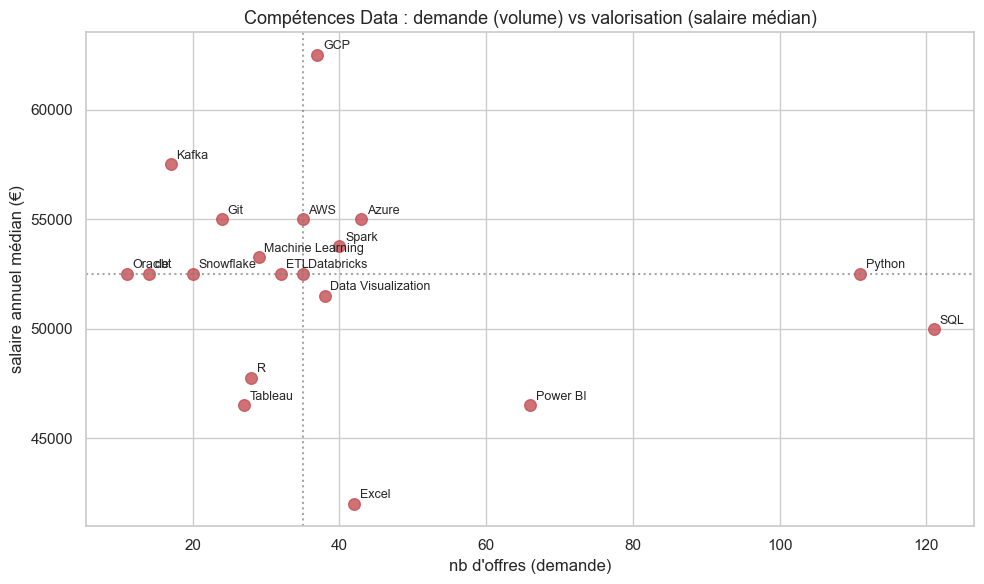

In [7]:
m = top.merge(csal, on="competence")
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(m["nb_offres"], m["salaire_median"], s=70, color="#C44E52", alpha=0.8)
for _, r in m.iterrows():
    ax.annotate(r["competence"], (r["nb_offres"], r["salaire_median"]),
                xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.axhline(m["salaire_median"].median(), color="gray", ls=":", alpha=0.7)
ax.axvline(m["nb_offres"].median(), color="gray", ls=":", alpha=0.7)
ax.set_title("Compétences Data : demande (volume) vs valorisation (salaire médian)")
ax.set_xlabel("nb d'offres (demande)"); ax.set_ylabel("salaire annuel médian (€)")
plt.tight_layout(); plt.show()

## 6. Conclusion de l'analyse

**Réponse à la question fil rouge :**

- **Compétences les plus demandées en IDF :** un socle **SQL + Python**, complété
  par la **BI/dataviz** (Power BI, Excel, Tableau) et l'**écosystème cloud/big data**
  (Azure, GCP, AWS, Spark, Databricks).
- **Valorisation :** les compétences **cloud et big data** se rémunèrent au-dessus
  du socle analytique. Autrement dit, SQL/Python sont nécessaires mais peu
  différenciants salarialement ; ce sont l'**ingénierie de la donnée** et le
  **cloud** qui tirent les salaires vers le haut.
- **Profil le plus valorisé :** un *data engineer* maîtrisant un cloud (Azure/GCP/AWS)
  et le traitement distribué (Spark/Databricks), plus que le *data analyst* BI seul.

**Limites (développées dans la conclusion du dossier, livrable V) :** salaire
renseigné sur une minorité d'offres, détection lexicale des compétences avec de
rares faux positifs, et biais de la source (offres France Travail ≠ marché total,
notamment les postes cadres souvent diffusés via d'autres canaux).